In [17]:
import xarray as xr
import gcsfs

# authenticated access using Google Cloud Storage (GCS) file system (GCSFileSystem)
fs = gcsfs.GCSFileSystem()

path = 'gs://leap-persistent/mvanlierwalq/dycoms_boss_pr6out_2/cm1out_000063.nc'

#with fs.open(path, 'rb') as f:     #####xarray does NOT load all data immediately, can create ValueError: I/O operation on closed file
#    ds = xr.open_dataset(f)

########xarray manages the cloud connection internally,
ds = xr.open_dataset(
    "gs://leap-persistent/mvanlierwalq/dycoms_boss_pr6out_2/cm1out_000063.nc",
    engine="h5netcdf",
    backend_kwargs={
        "storage_options": {"token": "cloud"}
    }
)
ds

/tmp/ipykernel_2163/3059747953.py:13: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(


<xarray.Dataset> Size: 164MB
Dimensions:     (one: 1, time: 1, yh: 128, xh: 128, zh: 96, zf: 97, xf: 129,
                 yf: 129)
Coordinates:
  * time        (time) timedelta64[ns] 8B 05:10:00
  * yh          (yh) float32 512B 0.025 0.075 0.125 0.175 ... 6.275 6.325 6.375
  * xh          (xh) float32 512B 0.025 0.075 0.125 0.175 ... 6.275 6.325 6.375
  * zh          (zh) float32 384B 0.0025 0.0076 0.0129 ... 1.313 1.382 1.459
  * zf          (zf) float32 388B 0.0 0.005 0.0102 0.0156 ... 1.346 1.418 1.501
  * xf          (xf) float32 516B 0.0 0.05 0.1 0.15 0.2 ... 6.25 6.3 6.35 6.4
  * yf          (yf) float32 516B 0.0 0.05 0.1 0.15 0.2 ... 6.25 6.3 6.35 6.4
Dimensions without coordinates: one
Data variables: (12/30)
    f_cor       (one) float32 4B ...
    ztop        (one) float32 4B ...
    cwp         (time, yh, xh) float32 66kB ...
    lwp         (time, yh, xh) float32 66kB ...
    th          (time, zh, yh, xh) float32 6MB ...
    prs         (time, zh, yh, xh) float32 6MB ...
    ...          ...
    scnc        (time, zh, yh, xh) float32 6MB ...
    scnr        (time, zh, yh, xh) float32 6MB ...
    nucnc       (time, zh, yh, xh) float32 6MB ...
    condevapqc  (time, zh, yh, xh) float32 6MB ...
    condevapqr  (time, zh, yh, xh) float32 6MB ...
    tke         (time, zf, yh, xh) float32 6MB ...
Attributes: (12/71)
    CM1 version:    cm1r21.0
    Conventions:    CF-1.7
    missing_value:  -999999.9
    x_units:        km
    x_label:        x
    y_units:        km
    ...             ...
    cgt1:           1.968889
    cgt2:           -1.4550738
    cgt3:           0.4861849
    dgt1:           2.2402363
    dgt2:           -3.5515
    dgt3:           1.3112639

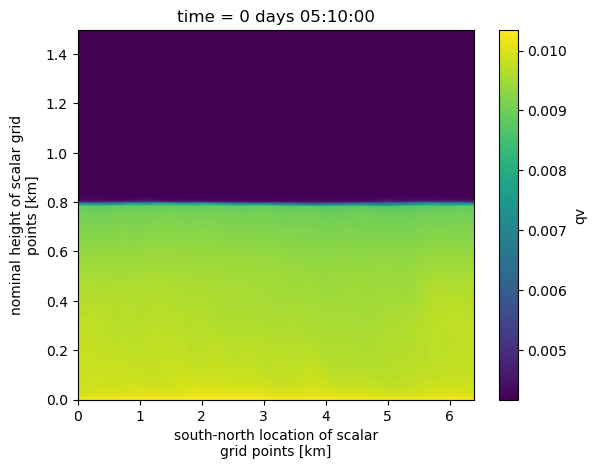

In [31]:
ds.qv.mean("xh").plot(y='zh')